In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.datasets import load_iris
from minisom import MiniSom

# Create 'figures' folder if it doesn't exist
figures_path = os.path.join(os.getcwd(), "figures")
if not os.path.exists(figures_path):
    os.makedirs(figures_path)
print("Figures folder created at:", figures_path)

Figures folder created at: C:\Users\pd25aat\OneDrive - University of Hertfordshire\individual project ML\figures


In [2]:
data = load_iris()
X = data.data      # features
y = data.target    # labels
print("Dataset shape:", X.shape)
print("Labels:", np.unique(y))

Dataset shape: (150, 4)
Labels: [0 1 2]


In [3]:
# SOM Parameters
som_size = 7
input_len = X.shape[1]
sigma = 1.0
learning_rate = 0.5
iterations = 100

# Initialize SOM
som = MiniSom(x=som_size, y=som_size, input_len=input_len, sigma=sigma, learning_rate=learning_rate)
som.random_weights_init(X)
som.train_random(X, iterations)

print("SOM training completed.")

SOM training completed.


In [4]:
# SOM Parameters
som_size = 7
input_len = X.shape[1]
sigma = 1.0
learning_rate = 0.5
iterations = 100

# Initialize SOM
som = MiniSom(x=som_size, y=som_size, input_len=input_len, sigma=sigma, learning_rate=learning_rate)
som.random_weights_init(X)
som.train_random(X, iterations)

print("SOM training completed.")

SOM training completed.


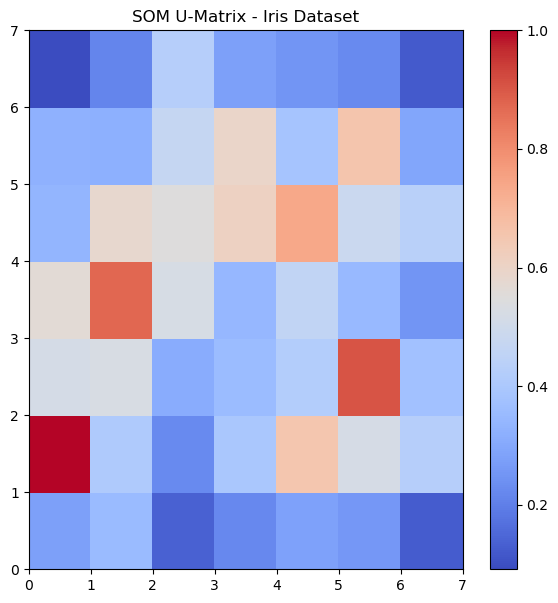

In [5]:
plt.figure(figsize=(7,7))
plt.pcolor(som.distance_map().T, cmap='coolwarm')
plt.colorbar()
plt.title("SOM U-Matrix - Iris Dataset")
plt.savefig(os.path.join(figures_path, "som_u_matrix.png"))
plt.show()

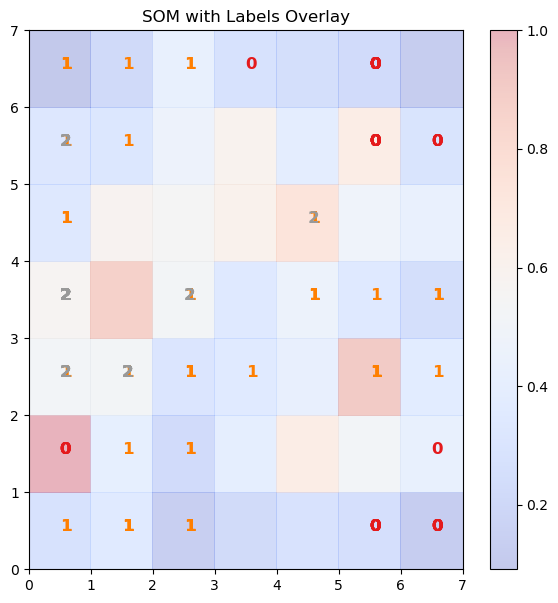

In [6]:
plt.figure(figsize=(7,7))
for i, x in enumerate(X):
    w = som.winner(x)
    plt.text(w[0]+0.5, w[1]+0.5, str(y[i]), color=plt.cm.Set1(y[i]/2.), fontdict={'weight':'bold','size':12})
plt.pcolor(som.distance_map().T, cmap='coolwarm', alpha=0.3)
plt.colorbar()
plt.title("SOM with Labels Overlay")
plt.savefig(os.path.join(figures_path, "som_labels_overlay.png"))
plt.show()

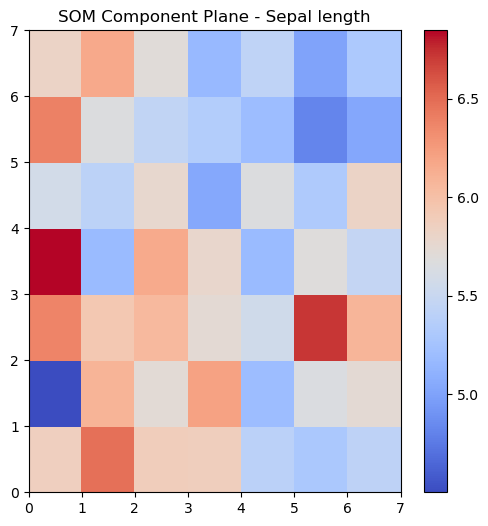

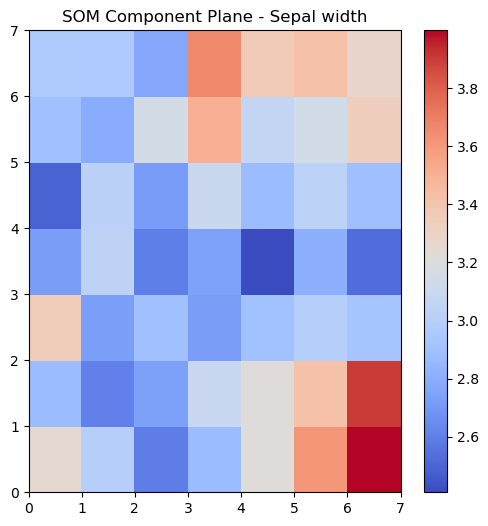

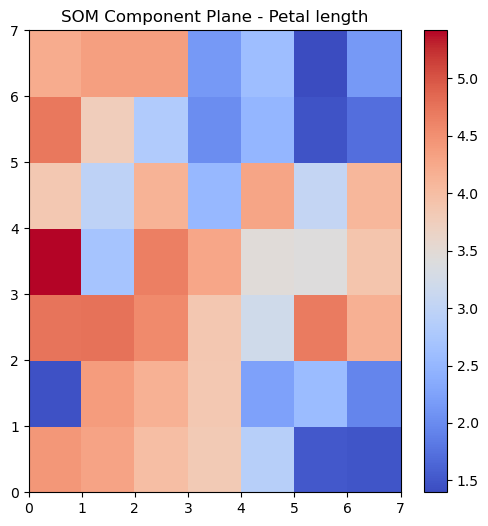

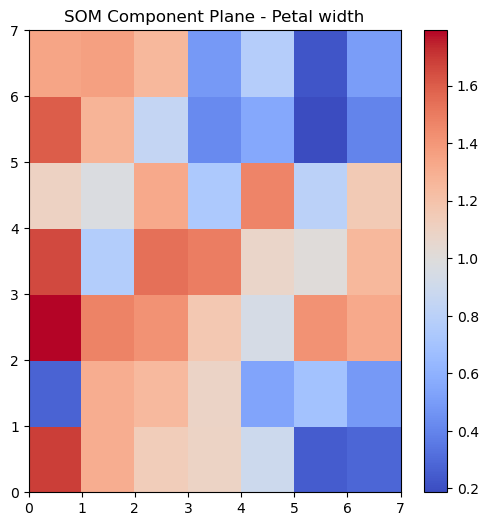

In [7]:
features = ['Sepal length', 'Sepal width', 'Petal length', 'Petal width']

for i in range(input_len):
    plt.figure(figsize=(6,6))
    plt.pcolor(som.get_weights()[:,:,i].T, cmap='coolwarm')
    plt.colorbar()
    plt.title(f"SOM Component Plane - {features[i]}")
    plt.savefig(os.path.join(figures_path, f"component_plane_{i}.png"))
    plt.show()